In [1]:
import sys
print(sys.executable)

D:\BrainTumorDetection\venv\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Everything is working!")

NumPy: 2.5.3
Pandas: 3.0.5
OpenCV: 5.0.0
Scikit-learn: 1.9.0
Everything is working!


In [3]:
import os
import cv2
import numpy as np

# Dataset paths
yes_path = r"D:\BrainTumorDetection\brain_tumor_dataset\yes"
no_path = r"D:\Brain Tumor Detection Dataset\brain_tumor_dataset\no"

# Check folders
print("YES folder exists:", os.path.exists(yes_path))
print("NO folder exists:", os.path.exists(no_path))

# Count images
yes_images = os.listdir(yes_path)
no_images = os.listdir(no_path)

print("Number of YES images:", len(yes_images))
print("Number of NO images:", len(no_images))

YES folder exists: True
NO folder exists: True
Number of YES images: 155
Number of NO images: 98


In [4]:
import os
import cv2
import numpy as np

IMG_SIZE = 128

X = []
y = []

# Load YES images → label 1
for filename in os.listdir(yes_path):
    file_path = os.path.join(yes_path, filename)

    img = cv2.imread(file_path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        X.append(img)
        y.append(1)

# Load NO images → label 0
for filename in os.listdir(no_path):
    file_path = os.path.join(no_path, filename)

    img = cv2.imread(file_path)

    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        X.append(img)
        y.append(0)

X = np.array(X)
y = np.array(y)

print("Images loaded:", len(X))
print("Image shape:", X.shape)
print("Labels shape:", y.shape)
print("YES:", np.sum(y == 1))
print("NO:", np.sum(y == 0))

Images loaded: 253
Image shape: (253, 128, 128)
Labels shape: (253,)
YES: 155
NO: 98


In [5]:
# Flatten each image into a single row
X_flat = X.reshape(X.shape[0], -1)

print("Original shape:", X.shape)
print("Flattened shape:", X_flat.shape)

Original shape: (253, 128, 128)
Flattened shape: (253, 16384)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])

Training images: 202
Testing images: 51


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Training data: (202, 16384)
Testing data: (51, 16384)


In [8]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=1, gamma="scale")

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully! ✅")

SVM model trained successfully! ✅


In [9]:
y_pred = svm_model.predict(X_test_scaled)

print("Predictions completed!")
print("First 10 predictions:", y_pred[:10])
print("Actual labels:", y_test[:10])

Predictions completed!
First 10 predictions: [0 1 0 1 0 1 1 1 1 1]
Actual labels: [0 1 0 1 0 1 1 0 1 0]


In [10]:
from sklearn.metrics import accuracy_score

train_pred = svm_model.predict(X_train_scaled)
test_pred = svm_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9554455445544554
Testing Accuracy: 0.8235294117647058


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("SVM Test Accuracy:", accuracy)
print("SVM Test Accuracy (%):", accuracy * 100)

SVM Test Accuracy: 0.8235294117647058
SVM Test Accuracy (%): 82.35294117647058


Confusion Matrix:
[[14  6]
 [ 3 28]]


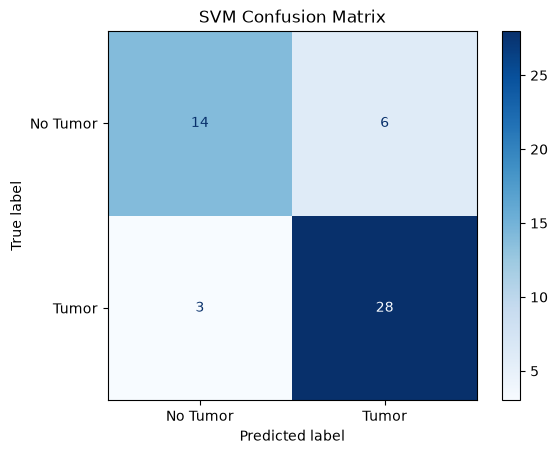

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

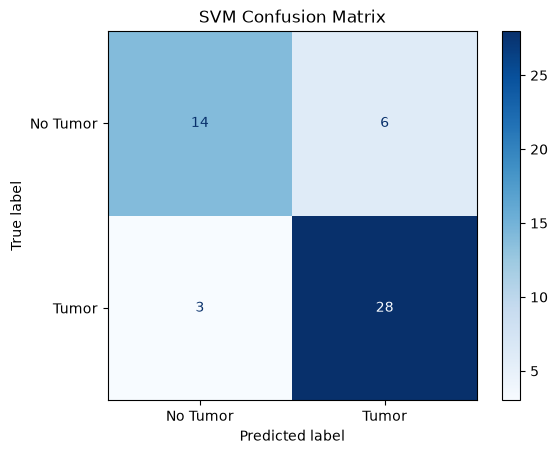

In [13]:
#Fixed the plotting error
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Tumor", "Tumor"]
)

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Tumor", "Tumor"]
))

Precision: 0.8235294117647058
Recall: 0.9032258064516129
F1-Score: 0.8615384615384616

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.82      0.70      0.76        20
       Tumor       0.82      0.90      0.86        31

    accuracy                           0.82        51
   macro avg       0.82      0.80      0.81        51
weighted avg       0.82      0.82      0.82        51



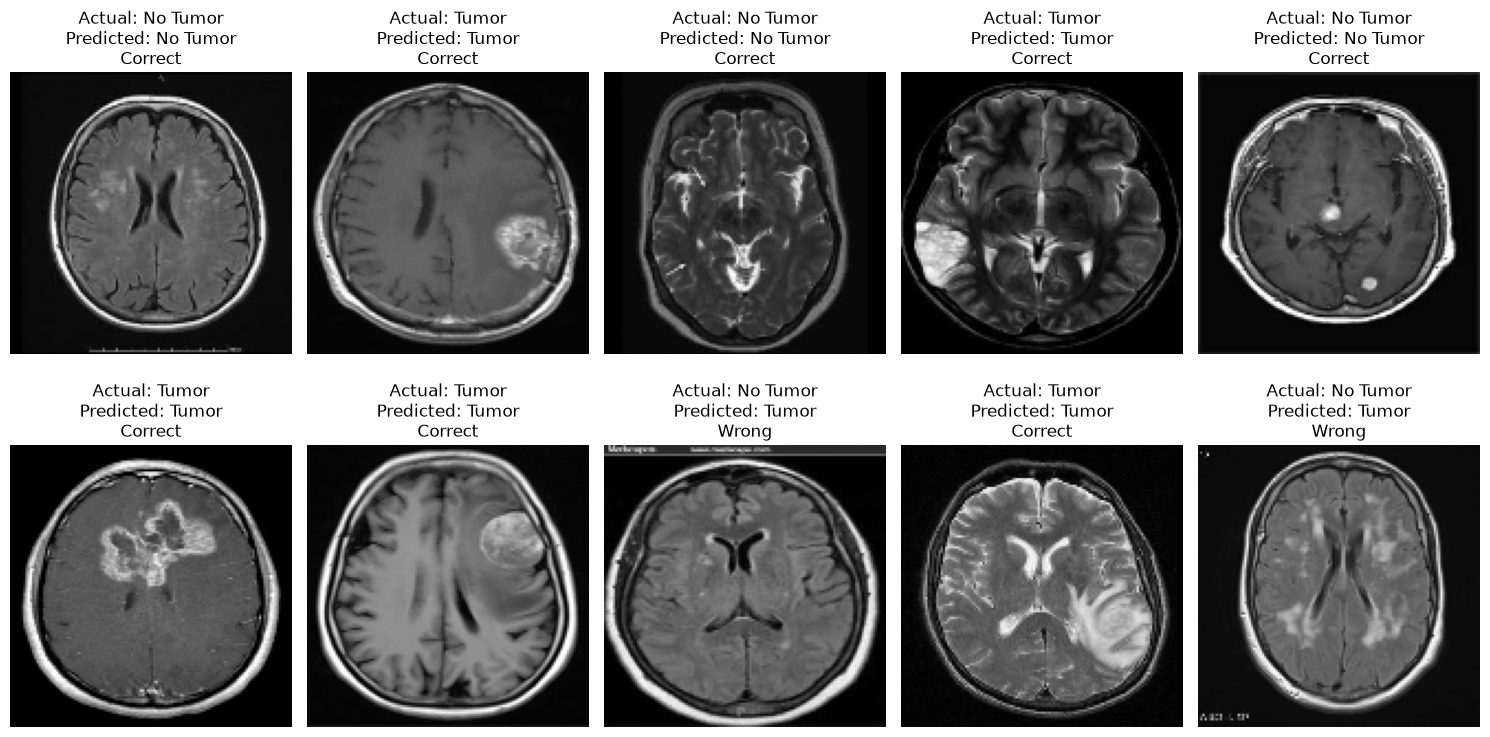

In [15]:
import matplotlib.pyplot as plt

# Show 10 test images
plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reshape flattened image back to 128x128
    image = X_test[i].reshape(128, 128)

    plt.imshow(image, cmap="gray")

    actual = "Tumor" if y_test[i] == 1 else "No Tumor"
    predicted = "Tumor" if y_pred[i] == 1 else "No Tumor"

    if actual == predicted:
        result = "Correct"
    else:
        result = "Wrong"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}\n{result}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
#test 16 different SVM configurations

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.7970731707317074


In [17]:
#Extract HOG features

from skimage.feature import hog

# Extract HOG features from all images
X_hog = []

for image in X:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (253, 8100)


In [19]:
pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 909.3 kB/s eta 0:00:13
   - -------------------------------------- 0.5/11.9 MB 909.3 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/11.9 MB 765.7 kB/s eta 0:00:15
   --- ------------------------------------ 1.0/11.9 MB 821.8 kB/s eta 0:00:14
   ---- ----------------------------------- 1.3/11.9 MB 910.9 kB/s eta 0:00:12
   ---- ----------------------------------- 1.3/11.9 MB 910.9 kB/s eta 0:00:12
   ------ --------------------------------- 1.8/11.9 MB 998.1 kB/s eta 0:00:11
   ------ --------------------------------- 1.8/11.9 MB 998.1 kB/s eta 0:00:11
   ------- -------------------------------- 2.1/11.9 MB 924.1 kB/s eta 0:00:11
   ------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
#Extract HOG features

from skimage.feature import hog

# Extract HOG features from all images
X_hog = []

for image in X:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (253, 8100)


In [19]:
#Split HOG features
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    X_hog,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training HOG:", X_train_hog.shape)
print("Testing HOG:", X_test_hog.shape)

Training HOG: (202, 8100)
Testing HOG: (51, 8100)


In [20]:
from sklearn.preprocessing import StandardScaler

hog_scaler = StandardScaler()

X_train_hog_scaled = hog_scaler.fit_transform(X_train_hog)
X_test_hog_scaled = hog_scaler.transform(X_test_hog)

print("HOG scaling completed!")

HOG scaling completed!


In [21]:
from sklearn.svm import SVC

hog_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

hog_svm.fit(X_train_hog_scaled, y_train_hog)

print("HOG + SVM model trained successfully! ✅")

HOG + SVM model trained successfully! ✅


In [22]:
from sklearn.metrics import accuracy_score

y_pred_hog = hog_svm.predict(X_test_hog_scaled)

hog_accuracy = accuracy_score(y_test_hog, y_pred_hog)

print("HOG + SVM Test Accuracy:", hog_accuracy)
print("HOG + SVM Test Accuracy (%):", hog_accuracy * 100)

HOG + SVM Test Accuracy: 0.8823529411764706
HOG + SVM Test Accuracy (%): 88.23529411764706


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid_hog = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001],
    "kernel": ["rbf", "linear"]
}

hog_grid = GridSearchCV(
    SVC(),
    param_grid_hog,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

hog_grid.fit(X_train_hog_scaled, y_train_hog)

print("Best HOG Parameters:", hog_grid.best_params_)
print("Best HOG Cross-Validation Accuracy:", hog_grid.best_score_)

Best HOG Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best HOG Cross-Validation Accuracy: 0.8567073170731708


In [26]:
best_hog_svm = hog_grid.best_estimator_

y_pred_best_hog = best_hog_svm.predict(X_test_hog_scaled)

best_hog_accuracy = accuracy_score(
    y_test_hog,
    y_pred_best_hog
)

print("Best HOG + SVM Test Accuracy:", best_hog_accuracy)
print("Best HOG + SVM Test Accuracy (%):", best_hog_accuracy * 100)

Best HOG + SVM Test Accuracy: 0.8823529411764706
Best HOG + SVM Test Accuracy (%): 88.23529411764706


In [27]:
#Evaluate the HOG model properly
from sklearn.metrics import confusion_matrix, classification_report

cm_hog = confusion_matrix(y_test_hog, y_pred_best_hog)

print("HOG + SVM Confusion Matrix:")
print(cm_hog)

print("\nHOG + SVM Classification Report:")
print(classification_report(
    y_test_hog,
    y_pred_best_hog,
    target_names=["No Tumor", "Tumor"]
))

HOG + SVM Confusion Matrix:
[[16  4]
 [ 2 29]]

HOG + SVM Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.89      0.80      0.84        20
       Tumor       0.88      0.94      0.91        31

    accuracy                           0.88        51
   macro avg       0.88      0.87      0.87        51
weighted avg       0.88      0.88      0.88        51



In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

cv_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

cv_scores = cross_val_score(
    cv_model,
    X_hog,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-Fold CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())
print("Average CV Accuracy (%):", cv_scores.mean() * 100)

5-Fold CV Scores: [0.80392157 0.92156863 0.7254902  0.94       0.86      ]
Average CV Accuracy: 0.8501960784313726
Average CV Accuracy (%): 85.01960784313725


In [30]:
import cv2
import numpy as np

# Split original images into training and testing
X_train_images, X_test_images, y_train_images, y_test_images = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Original training images:", len(X_train_images))
print("Test images:", len(X_test_images))

Original training images: 202
Test images: 51


In [31]:
X_augmented = []
y_augmented = []

for image, label in zip(X_train_images, y_train_images):

    # Keep original image
    X_augmented.append(image)
    y_augmented.append(label)

    # 1. Horizontal flip
    flipped = cv2.flip(image, 1)
    X_augmented.append(flipped)
    y_augmented.append(label)

    # 2. Small rotation
    h, w = image.shape
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, 10, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))

    X_augmented.append(rotated)
    y_augmented.append(label)

X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

print("Original training images:", len(X_train_images))
print("Augmented training images:", len(X_augmented))
print("Test images:", len(X_test_images))

Original training images: 202
Augmented training images: 606
Test images: 51


In [32]:
X_test_hog_final = []

for image in X_test_images:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_test_hog_final.append(features)

X_test_hog_final = np.array(X_test_hog_final)

print("Test HOG shape:", X_test_hog_final.shape)

Test HOG shape: (51, 8100)


In [34]:
X_test_hog_final = []

for image in X_test_images:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_test_hog_final.append(features)

X_test_hog_final = np.array(X_test_hog_final)

print("Test HOG shape:", X_test_hog_final.shape)

Test HOG shape: (51, 8100)


In [36]:
X_test_hog_final = []

for image in X_test_images:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_test_hog_final.append(features)

X_test_hog_final = np.array(X_test_hog_final)

print("Test HOG shape:", X_test_hog_final.shape)

Test HOG shape: (51, 8100)


In [37]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_aug_hog_scaled = final_scaler.fit_transform(X_aug_hog)
X_test_hog_final_scaled = final_scaler.transform(X_test_hog_final)

print("Feature scaling completed!")

NameError: name 'X_aug_hog' is not defined

In [38]:
print("X_augmented:", "YES" if "X_augmented" in globals() else "NO")
print("y_augmented:", "YES" if "y_augmented" in globals() else "NO")
print("X_aug_hog:", "YES" if "X_aug_hog" in globals() else "NO")
print("X_test_images:", "YES" if "X_test_images" in globals() else "NO")

X_augmented: YES
y_augmented: YES
X_aug_hog: NO
X_test_images: YES


In [39]:
from skimage.feature import hog

X_aug_hog = []

for image in X_augmented:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_aug_hog.append(features)

X_aug_hog = np.array(X_aug_hog)

print("Augmented HOG shape:", X_aug_hog.shape)
print("Labels shape:", y_augmented.shape)

Augmented HOG shape: (606, 8100)
Labels shape: (606,)


In [40]:
X_test_hog_final = []

for image in X_test_images:
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    X_test_hog_final.append(features)

X_test_hog_final = np.array(X_test_hog_final)

print("Test HOG shape:", X_test_hog_final.shape)

Test HOG shape: (51, 8100)


In [41]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_aug_hog_scaled = final_scaler.fit_transform(X_aug_hog)
X_test_hog_final_scaled = final_scaler.transform(X_test_hog_final)

print("Feature scaling completed!")

Feature scaling completed!


In [42]:
from sklearn.svm import SVC

aug_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

aug_svm.fit(X_aug_hog_scaled, y_augmented)

print("Augmented HOG + SVM trained successfully! ✅")

Augmented HOG + SVM trained successfully! ✅


In [43]:
y_pred_aug = aug_svm.predict(X_test_hog_final_scaled)

print("Predictions completed!")

Predictions completed!


In [3]:
from sklearn.metrics import accuracy_score

aug_accuracy = accuracy_score(y_test_images, y_pred_aug)

print("Augmented HOG + SVM Accuracy:", aug_accuracy)
print("Augmented HOG + SVM Accuracy (%):", aug_accuracy * 100)

NameError: name 'y_test_images' is not defined

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test_images, y_pred_aug))

cm = confusion_matrix(y_test_images, y_pred_aug)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Augmented HOG + SVM")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.90      0.90      0.90        31

    accuracy                           0.88        51
   macro avg       0.88      0.88      0.88        51
weighted avg       0.88      0.88      0.88        51

Confusion Matrix:
[[17  3]
 [ 3 28]]


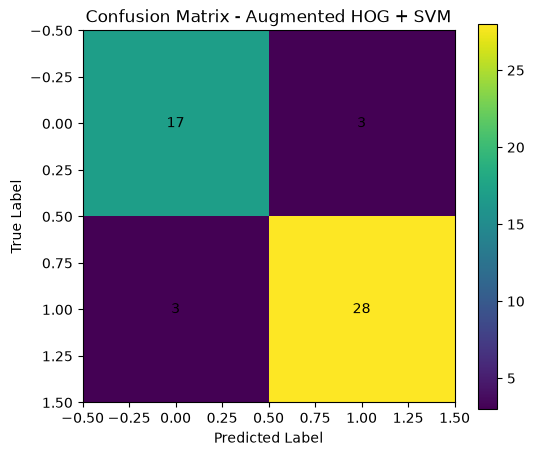

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test_images, y_pred_aug))

cm = confusion_matrix(y_test_images, y_pred_aug)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Augmented HOG + SVM")

# Add numbers inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Find correct and incorrect predictions
correct = np.where(y_pred_aug == y_test_images)[0]
incorrect = np.where(y_pred_aug != y_test_images)[0]

print("Correct predictions:", len(correct))
print("Incorrect predictions:", len(incorrect))

Correct predictions: 45
Incorrect predictions: 6


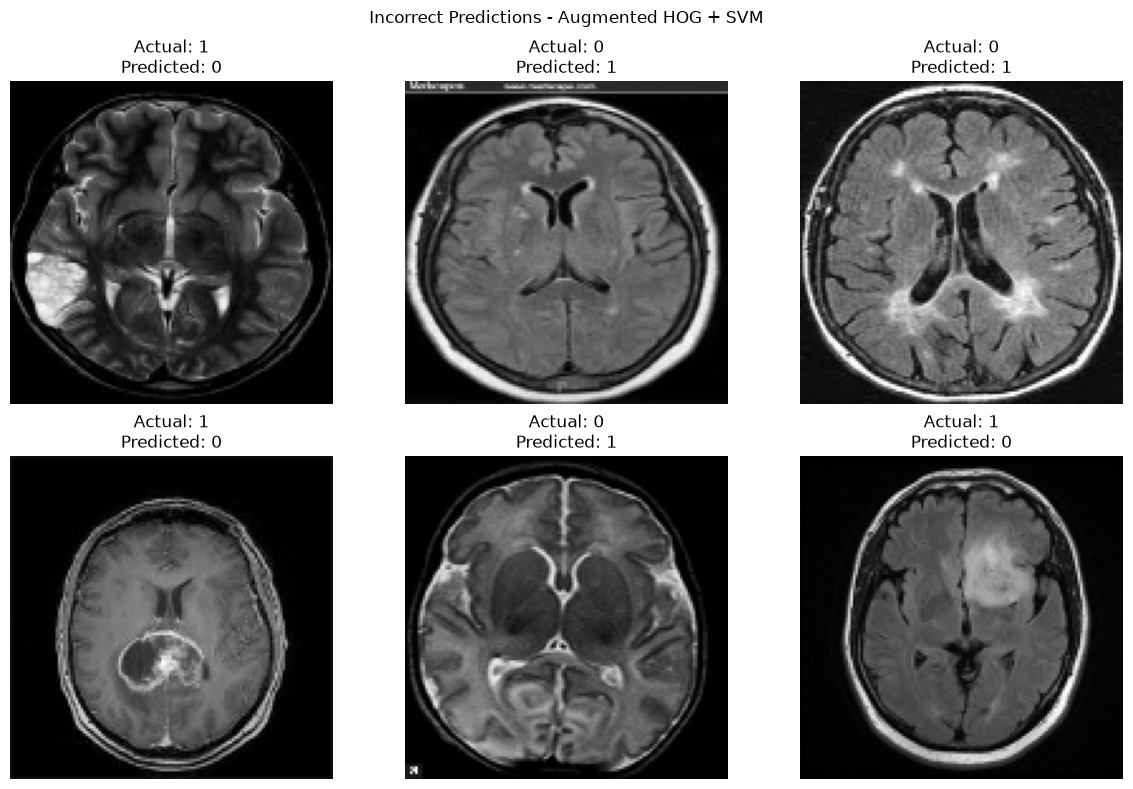

In [48]:
plt.figure(figsize=(12, 8))

num_images = min(6, len(incorrect))

for i in range(num_images):
    idx = incorrect[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test_images[idx], cmap="gray")

    plt.title(
        f"Actual: {y_test_images[idx]}\n"
        f"Predicted: {y_pred_aug[idx]}"
    )

    plt.axis("off")

plt.suptitle("Incorrect Predictions - Augmented HOG + SVM")
plt.tight_layout()
plt.show()

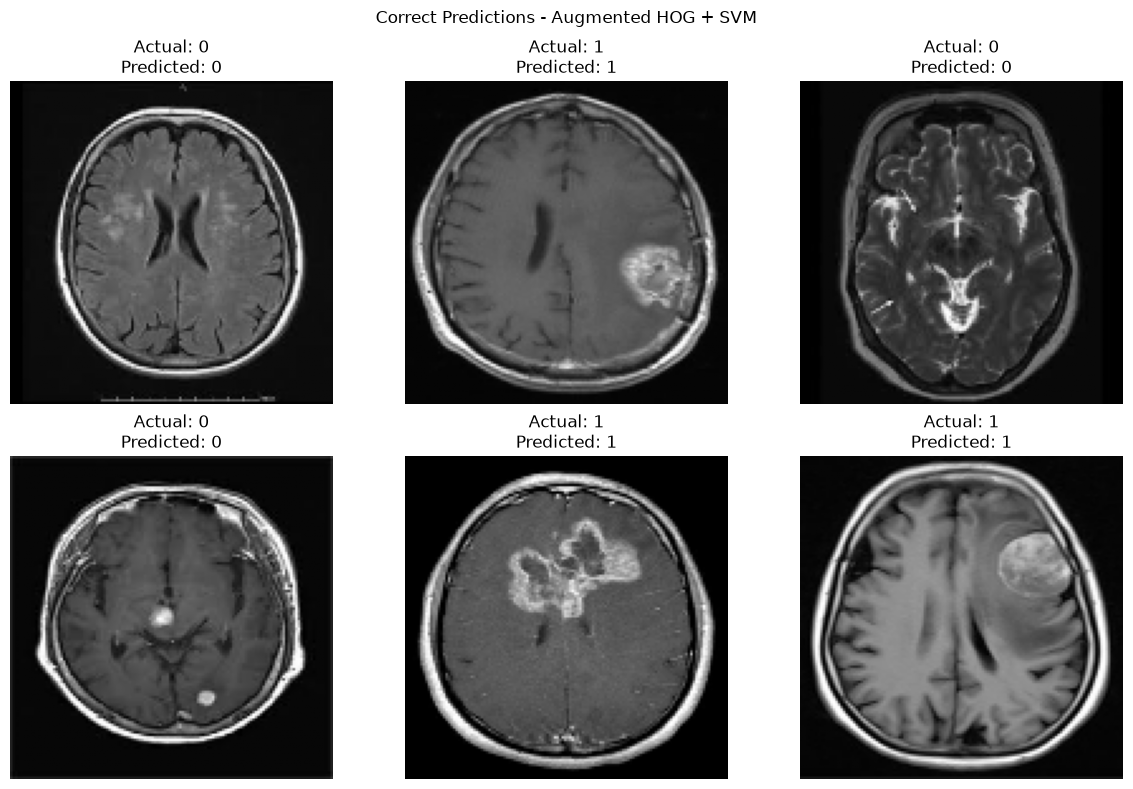

In [53]:
plt.figure(figsize=(12, 8))

num_images = min(6, len(correct))

for i in range(num_images):
    idx = correct[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test_images[idx], cmap="gray")

    plt.title(
        f"Actual: {y_test_images[idx]}\n"
        f"Predicted: {y_pred_aug[idx]}"
    )

    plt.axis("off")

plt.suptitle("Correct Predictions - Augmented HOG + SVM")
plt.tight_layout()
plt.show()

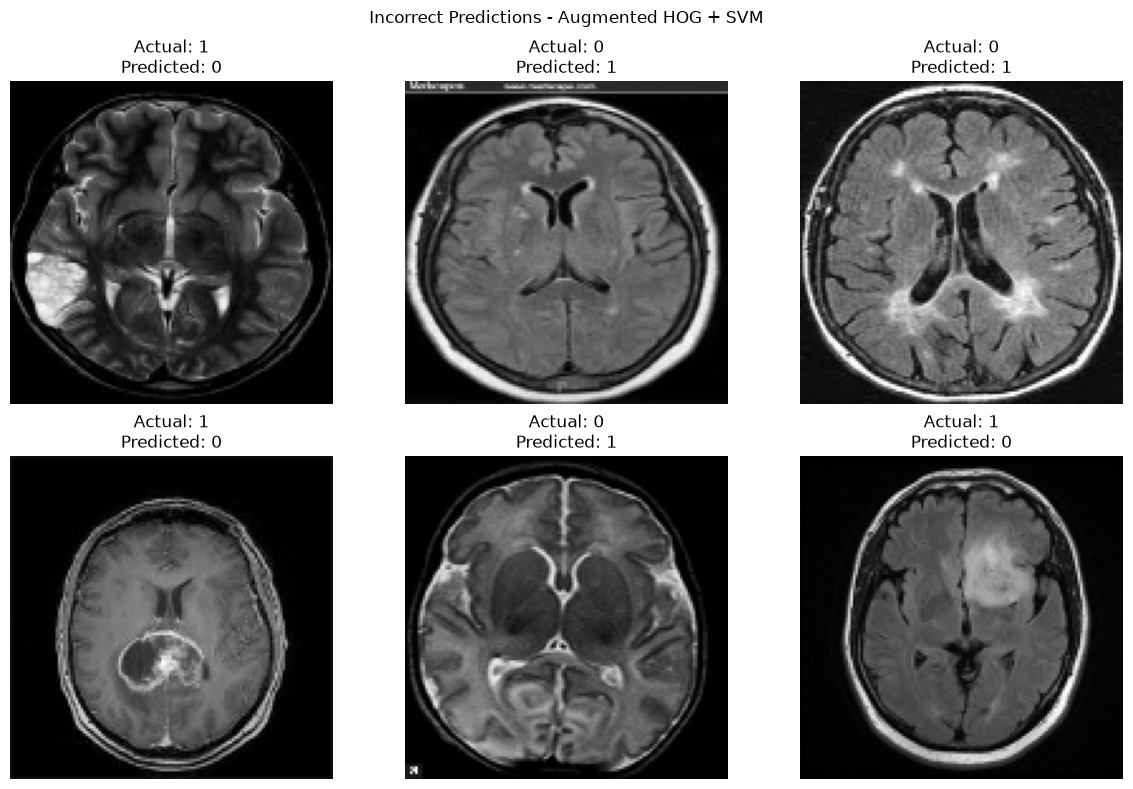

In [54]:
plt.figure(figsize=(12, 8))

for i in range(len(incorrect)):
    idx = incorrect[i]

    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test_images[idx], cmap="gray")

    plt.title(
        f"Actual: {y_test_images[idx]}\n"
        f"Predicted: {y_pred_aug[idx]}"
    )

    plt.axis("off")

plt.suptitle("Incorrect Predictions - Augmented HOG + SVM")
plt.tight_layout()
plt.show()

AUC: 0.9725806451612903
AUC (%): 97.25806451612902


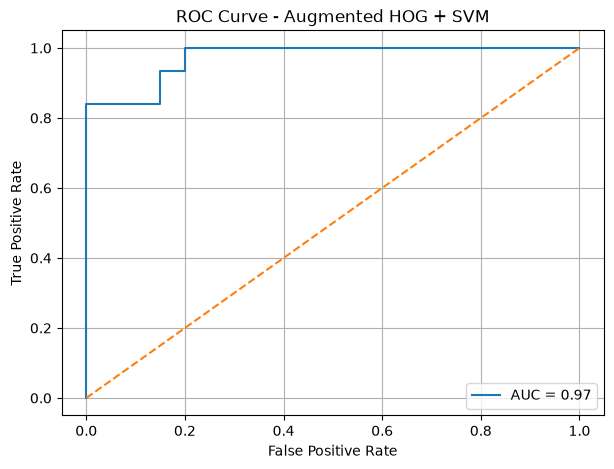

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get decision scores from the trained SVM
y_score = aug_svm.decision_function(X_test_hog_final_scaled)

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test_images, y_score)

# Calculate AUC
auc_score = roc_auc_score(y_test_images, y_score)

print("AUC:", auc_score)
print("AUC (%):", auc_score * 100)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Augmented HOG + SVM")
plt.legend()
plt.grid()

plt.show()

In [56]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Raw Pixel + SVM",
        "HOG + SVM",
        "Augmented HOG + SVM"
    ],
    "Accuracy (%)": [
        82.35,
        88.24,
        88.24
    ]
})

print(results)

                 Model  Accuracy (%)
0      Raw Pixel + SVM         82.35
1            HOG + SVM         88.24
2  Augmented HOG + SVM         88.24


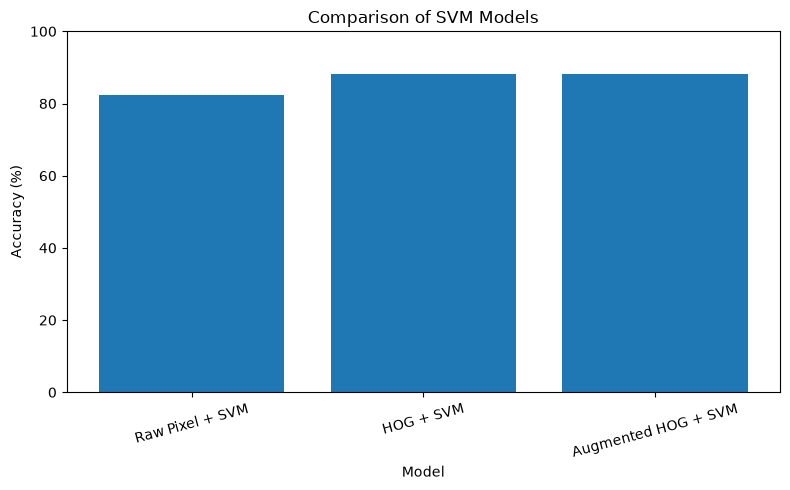

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of SVM Models")
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [58]:
import joblib

joblib.dump(aug_svm, "augmented_hog_svm_model.pkl")
joblib.dump(final_scaler, "hog_scaler.pkl")

print("Model and scaler saved successfully! ✅")

Model and scaler saved successfully! ✅


In [59]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

In [60]:
new_image_path = r"D:\BrainTumorDetection\test_image.jpg"

In [63]:
import os
import cv2

new_image_path = r"D:\Brain Tumor Detection Dataset\brain_tumor_dataset\no"

print("File exists:", os.path.exists(new_image_path))

new_image = cv2.imread(new_image_path, cv2.IMREAD_GRAYSCALE)

print("Image loaded:", new_image is not None)

File exists: True
Image loaded: False


In [64]:
from PIL import Image

try:
    img = Image.open(new_image_path)
    print("Image format:", img.format)
    print("Image size:", img.size)
    print("Image mode:", img.mode)
except Exception as e:
    print("Error:", e)

Error: [Errno 13] Permission denied: 'D:\\Brain Tumor Detection Dataset\\brain_tumor_dataset\\no'


In [68]:
import os

folder = r"D:\Brain Tumor Detection Dataset\brain_tumor_dataset\no\no1.jpg"

files = os.listdir(folder)

print("Number of files:", len(files))
print(files[:10])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Brain Tumor Detection Dataset\\brain_tumor_dataset\\no\\no1.jpg'

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open(new_image_path).convert("L")
img = img.resize((128, 128))

new_image = np.array(img)

print("Image loaded successfully!")
print("Image shape:", new_image.shape)

NameError: name 'new_image_path' is not defined

In [2]:
y_pred = model.predict(X_test)

NameError: name 'model' is not defined